In [50]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import UnivariateSpline

In [63]:
def plot_training_curve(file_path, title, metric_name = "Accuracy", layers=None):
    df = pd.read_csv(file_path, sep="\t")
    plt.figure(figsize=(12, 6))
    for index, row in df.iterrows():
        if layers is not None and index not in layers:
            continue
        plt.plot([int(x) for x in df.columns], row, label=f'Layer {index+1}')
        
    plt.xlabel('Step')
    plt.ylabel(metric_name)
    plt.legend()
    plt.title(title)
    
    plt.show()

In [60]:
def plot_pair_training_curve(target_path, dependent_path, title, metric_name = "Accuracy", layers=None):
    df_target = pd.read_csv(target_path, sep="\t")
    df_dep = pd.read_csv(dependent_path, sep="\t")
    plt.figure(figsize=(20, 6))
    # make the x axis logarithmic
    #plt.xscale('log')
    for index, row in df_target.iterrows():
        if layers is not None and index not in layers:
            continue
        x_target, y_target = [int(x) for x in df_target.columns], row
        spline = UnivariateSpline(x_target, y_target, s=0.1)
        y_smooth = spline(x_target)
        plt.plot([int(x) for x in df_target.columns], row, label=f'Layer {index+1} To')
        #plt.plot(x_target, y_smooth, label=f'Layer {index+1} Target')

        x_dependent, y_dependent = [int(x) for x in df_dep.columns], df_dep.iloc[index]
        spline = UnivariateSpline(x_dependent, y_dependent)
        y_smooth = spline(x_dependent)
        plt.plot([int(x) for x in df_dep.columns], df_dep.iloc[index], label=f'Layer {index+1} Verb')
        #plt.plot(x_dependent, y_smooth, label=f'Layer {index+1} Dependent')        
    
    plt.xlabel('Step')
    plt.ylabel(metric_name)
    
    plt.title(title)
    plt.legend()
    plt.show()

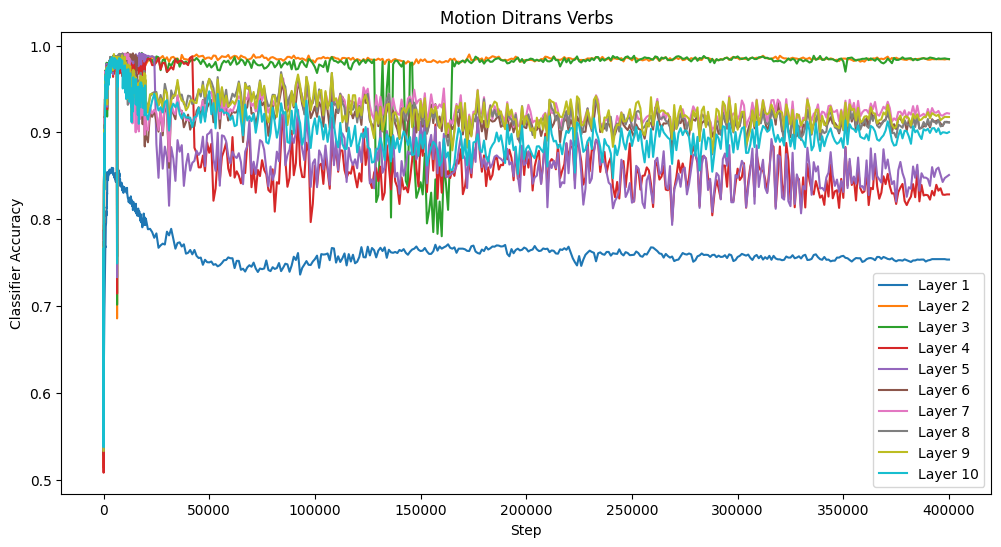

In [64]:
plot_training_curve("/sailhome/jjian/projects/abstraction/results/wikitext/to/ridge_pca_2/battlestar_small.motion.ditrans.dependent.tsv", "Motion Ditrans Verbs", metric_name="Classifier Accuracy", layers=list(range(10)))

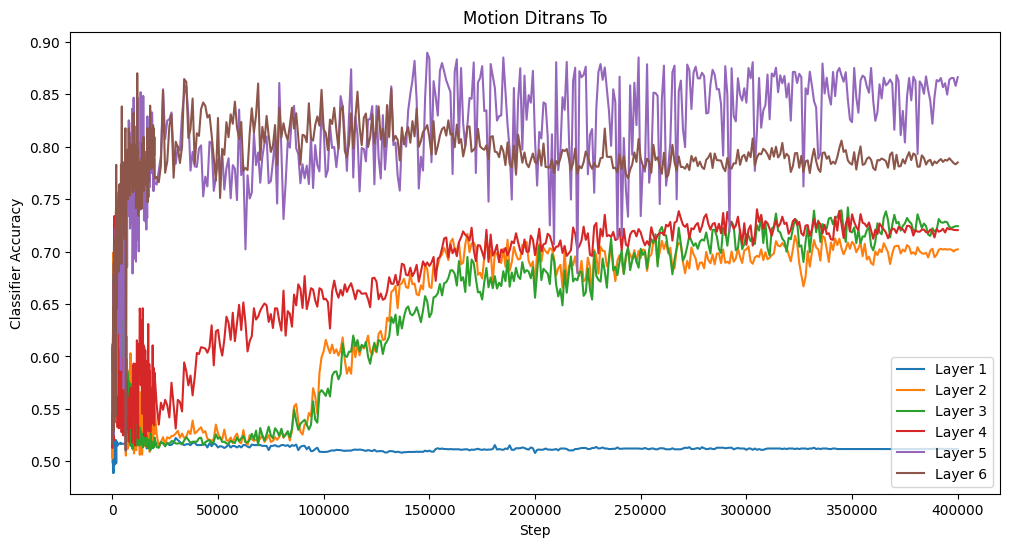

In [65]:
plot_training_curve("/sailhome/jjian/projects/abstraction/results/wikitext/to/ridge_pca_2/battlestar_small.motion.ditrans.target.tsv", "Motion Ditrans To", metric_name="Classifier Accuracy", layers=list(range(6)))

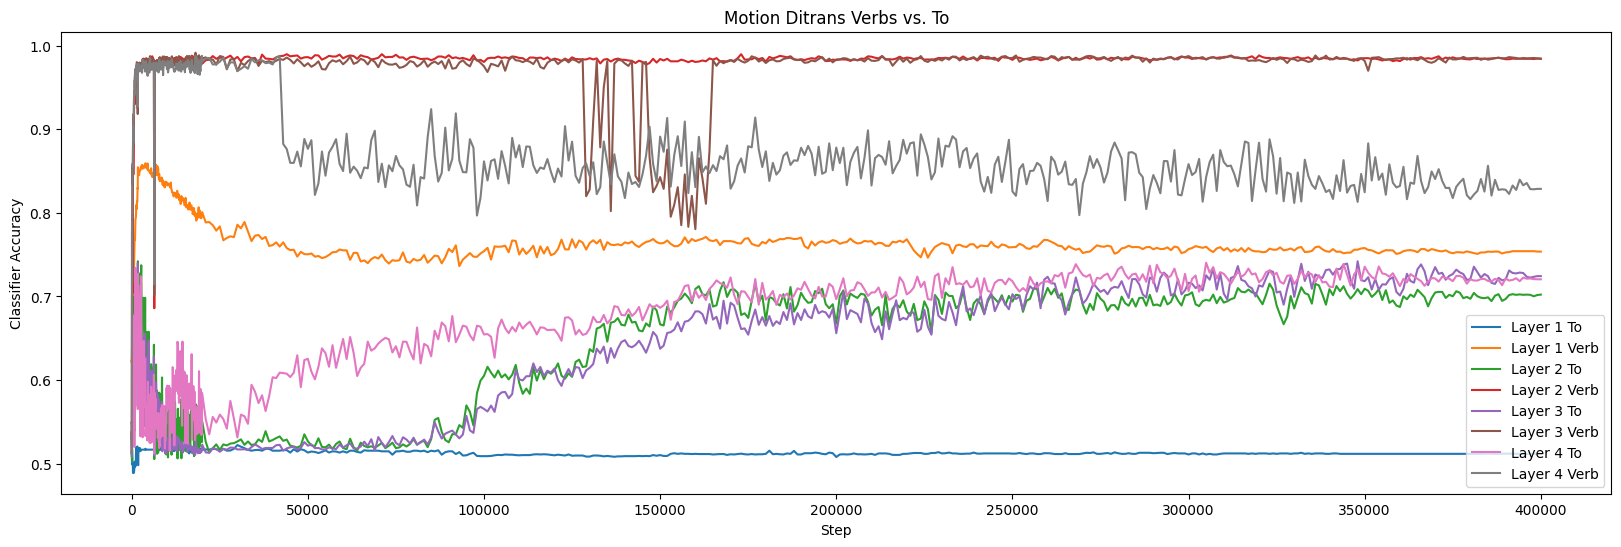

In [61]:
plot_pair_training_curve("/sailhome/jjian/projects/abstraction/results/wikitext/to/ridge_pca_2/battlestar_small.motion.ditrans.target.tsv","/sailhome/jjian/projects/abstraction/results/wikitext/to/ridge_pca_2/battlestar_small.motion.ditrans.dependent.tsv", "Motion Ditrans Verbs vs. To", metric_name="Classifier Accuracy", layers=list(range(4)))